# Model agreement vs LLM judges on long rule sentences (R_COMP)

This notebook is a runnable demo of the **R_COMP** experiment. The question is whether **cross-family model agreement (consensus)** can predict if an NL→FOL translation is faithful to its sentence, with no gold formula, and how it compares with **LLM-as-judge** scores.

**Setup of the original experiment**
- **R_COMP**: 221 templated long rule sentences (≥25 words, ≥3 conditions, one *unless / except / provided that / only if* clause). The references are trusted by construction: each sentence has a *weak* and a *strong* reading.
- 10 few-shot LLM slots (9 vendor families) translate every sentence. In the **SIG** condition each model is also given the predicate signature.
- **Labels (SIG)**: pure z3 equivalence to the weak or strong reading (CORRECT / ERROR / READING_CHOICE / OFF_SIGNATURE / UNPARSEABLE).
- **Metric `c_score_sig`**: the share of *family-disjoint peers* whose translation is **not** z3-equivalent to the candidate. Higher means more likely an error.
- **Pre-registered primary test**: within-template AUROC of `c_score_sig` vs the disguised `gemini-2.5-flash-lite` rubric judge (`judge_cheap_disg`). Full run: **0.954 vs 0.587, delta +0.367 [0.328, 0.404] → PASS**.

**What this notebook runs**
1. `build()` from the original `method.py`. It turns the per-row candidate records into the `exp_gen_sol_out`-style `method_out.json` (dataset `R_COMP_SIG`, one example per candidate, `predict_*` scores, `metadata_*` fields).
2. The reusable metric `consensus_exact` from `src/consensus_rcomp.py`, together with the z3 FOL parser it depends on (`rcomp/labeller/fol.py`). It re-derives `c_score_sig` from the raw candidate formulas.
3. The stratified AUROC and bootstrap code from `src/auc_tools.py` and `src/analyse.py`, applied to the demo subset for the primary comparison.

The expensive stages were LLM generation, LLM judges and the local Qwen3-8B judge (about $1.58 total). They are **not** re-run here. Their per-row outputs are already in the data.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru, z3-solver — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3', 'z3-solver==5.1.0.0')

# numpy, pandas, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports
The first block is the original import block of `method.py`. The second adds the imports used by the vendored helpers (`fol.py`, `consensus_rcomp.py`, `auc_tools.py`) and by the plots.

In [2]:
from __future__ import annotations

import argparse
import json
import subprocess
import sys
from pathlib import Path

from loguru import logger

# extra imports for the vendored helpers + visualisation
import re
import signal
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import z3
import matplotlib.pyplot as plt

## Data loading
`mini_demo_data.json` is a curated subset of the full run: **10 sentences** (one per template T1–T9, plus one extra T7 sentence that also has READING_CHOICE / OFF_SIGNATURE / UNPARSEABLE rows) × **10 SIG translation slots = 100 candidate rows**. It contains:
- `rows`: the per-candidate records of `results/rcomp_candidates.jsonl`, with labels, strata, z3 class ids, and every consensus and judge score.
- `sentences`: the sentence text with its weak and strong reference FOL (from `rcomp/work/rcomp_sentences.json`).
- `family_map_vendor`: the slot → vendor-family map, used to keep peers family-disjoint.
- `analysis` / `testability`: the full-run headline numbers that `build()` copies into the output metadata.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-3/experiment-7/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{len(data['sentences'])} sentences, {len(data['rows'])} candidate rows")
print("labels:", dict(Counter(r["label"] for r in data["rows"])))

R_COMP_SIG demo subset: 10 templated long rule sentences (one per template T1-T9 + one extra) x 10 few-shot LLM translation slots = 100 candidate rows, with z3 labels, all consensus/judge scores, sentence references, the vendor family map and the full-run headline numbers.
10 sentences, 100 candidate rows
labels: {'ERROR': 25, 'CORRECT': 69, 'OFF_SIGNATURE': 1, 'READING_CHOICE': 4, 'UNPARSEABLE': 1}


## Configuration
All tunable parameters live here. The original values are noted in the comments.
- `N_SENTENCES`: how many of the 10 demo sentences to process. Each sentence brings all 10 of its candidate rows, because consensus needs the peers.
- `Z3_TIMEOUT_MS`, `PAIR_CAP_S`: z3 per-equivalence timeout and wall-clock cap per pair. Original: `ms=5000`, `pair_cap_s=30` (`consensus_exact` defaults).
- `B`: number of sentence-clustered, template-stratified bootstrap replicates for the AUROC CIs. Original: `--B 2000`.
- `SEED`: the bootstrap seed from `src/analyse.py`.

In [5]:
N_SENTENCES = 10        # demo subset has 10 sentences (full run: 221 sentences / 2,210 SIG rows)
Z3_TIMEOUT_MS = 5000    # original: 5000 ms per z3 equivalence check
PAIR_CAP_S = 30         # original: 30 s wall-clock cap per pair
B = 2000                # original: 2000 bootstrap replicates
SEED = 20260924         # original seed (src/analyse.py)
PRIMARY_BAR = "judge_cheap_disg"   # pre-registered comparator (src/analyse.py)

## Paths, logging and the output schema (from `method.py`)
In the original script these are module-level constants. `PRED` lists every score column, and all of them are oriented so that higher means more likely an ERROR. `META` lists the per-row metadata copied into the output.

*Notebook change:* `ROOT` is the current directory instead of `Path(__file__).parent`. The file log sink goes to `logs/method.log` next to the notebook.

In [6]:
ROOT = Path(".").resolve()   # original: Path(__file__).resolve().parent
RES = ROOT / "results"
RC = ROOT / "rcomp"

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

PRED = ["c_score_sig", "c_score_align", "c_score_nf", "c_score_hyb", "g_align", "g_nf", "judge_cheap_disg", "judge_cheap_orig",
        "judge_frontier_orig", "judge_frontier_disg", "judge_local_disg", "judge_local_orig"]
META = ["row_key", "item_id", "sentence_id", "template_id", "slot", "system", "family", "prompt_variant", "parse_ok",
        "label_source", "label_tier", "matched_reading", "off_signature", "sig_status", "repair_ops", "repair_status",
        "sig_class_id", "sig_class_id_size", "sig_class_id_n_peers", "sig_class_id_n_peers_same_class",
        "sig_class_id_peer_majority_class", "sig_class_id_is_peer_majority", "free_solver_class_id", "free_align_class_id",
        "free_hyb_class_id", "free_align_class_id_size", "free_align_class_id_is_peer_majority", "free_hyb_class_id_size",
        "free_hyb_class_id_is_peer_majority", "n_peers_sig", "n_peers_equal_sig", "n_unknown_sig", "n_peers_hyb",
        "correct_not_equivalent", "ref_flagged", "tier_B_provisional", "cost_usd", "secs_sig", "coverage_status"]


def run(cmd: list[str]) -> None:
    logger.info("$ " + " ".join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)


def fmt_pred(v) -> str:
    return "None" if v is None else f"{float(v):.6f}"

## Select the demo subset
Keep the first `N_SENTENCES` sentences and **all** of their candidate rows.

In [7]:
demo_sids = [s["sentence_id"] for s in data["sentences"][:N_SENTENCES]]
demo_rows = [r for r in data["rows"] if r["sentence_id"] in set(demo_sids)]
print(f"{len(demo_sids)} sentences, {len(demo_rows)} rows:", dict(Counter(r['label'] for r in demo_rows)))

10 sentences, 100 rows: {'ERROR': 25, 'CORRECT': 69, 'OFF_SIGNATURE': 1, 'READING_CHOICE': 4, 'UNPARSEABLE': 1}


## S11 `build()`: assemble `method_out.json`
This is the original `build()` from `method.py`. Every candidate row becomes one example:
- `input`: JSON with the sentence text, the candidate FOL and the condition.
- `output`: the z3 label.
- `predict_<metric>`: each score, as a 6-decimal string, or `"None"` when it was not computed. For example, the frontier judge only scored a 60-row subsample.
- `metadata_*`: the row's metadata and complexity strata.

*Notebook change:* the three file reads (`rcomp_sentences.json`, `rcomp_candidates.jsonl`, `analysis.json` / `testability_*.json`) now read from the loaded `data`, and the output is written to `./method_out.json`. The logic is unchanged.

In [8]:
@logger.catch(reraise=True)
def build() -> None:
    sents = {s["sentence_id"]: s for s in data["sentences"]}          # original: RC / "work" / "rcomp_sentences.json"
    rows = demo_rows                                                   # original: RES / "rcomp_candidates.jsonl"
    A = data["analysis"]                                               # original: RES / "analysis.json"
    ds = {"SIG": [], "FREE": []}
    for r in rows:
        s = sents[r["sentence_id"]]
        ex = {"input": json.dumps({"text": s["text"], "candidate_fol": r.get("candidate_fol") or "", "condition": r["condition"]}, ensure_ascii=False),
              "output": str(r["label"])}
        for m in PRED:
            ex[f"predict_{m}"] = fmt_pred(r.get(m))
        for k in META:
            v = r.get(k)
            ex[f"metadata_{k}"] = v
        for k, v in (r.get("strata") or {}).items():
            ex[f"metadata_{k}"] = v
        ex["metadata_condition"] = r["condition"]
        ds[r["condition"]].append(ex)
    sig = A["SIG"]
    meta = {"method_name": "cross-family consensus (SIG-exact, ALIGN, NF-anchored, HYB, graded) vs LLM judges on R_COMP",
            "orientation": "every predict_* score: higher = more likely ERROR; 'None' = not computed (see metadata)",
            "labels": {"SIG": "pure z3 equivalence to the weak or strong template reading (CORRECT / ERROR / READING_CHOICE / OFF_SIGNATURE / UNPARSEABLE)",
                       "FREE": "dataset-3 solver-modulo-alignment rule, tier A only (panel not run, deviation D9): CORRECT / ERROR / UNRESOLVED / UNPARSEABLE / NO_OUTPUT"},
            "primary_test": {k: sig["primary"].get(k) for k in ("n", "n_error", "n_correct", "n_sentences", "auroc_metric", "auroc_comparator",
                                                              "delta", "ci", "p_one_sided", "PASS")},
            "testability": {"SIG": data["testability"]["SIG"],        # original: RES / "testability_SIG.json"
                            "FREE": data["testability"].get("FREE")},  # original: RES / "testability_FREE.json"
            "frozen_params": "exp-5 prereg scoring_params (variants ALIGN + NF-anchored, k=5, tau 0.5, timeout 2000 ms, pair cap 30 s); no tuning on R_COMP",
            "results_files": ["results/analysis.json", "results/tables.md", "results/rcomp_candidates.jsonl", "results/deviations.json"]}
    out = {"metadata": meta, "datasets": [{"dataset": "R_COMP_SIG", "examples": ds["SIG"]}]}
    if ds["FREE"]:
        out["datasets"].append({"dataset": "R_COMP_FREE", "examples": ds["FREE"]})
    (ROOT / "method_out.json").write_text(json.dumps(out, ensure_ascii=False, indent=1))
    logger.info(f"method_out.json: SIG {len(ds['SIG'])} rows, FREE {len(ds['FREE'])} rows")

In [9]:
# original main(): `method.py build` -> build()
build()
method_out = json.loads((ROOT / "method_out.json").read_text())
ex0 = method_out["datasets"][0]["examples"][0]
print(json.dumps({k: ex0[k] for k in list(ex0)[:16]}, ensure_ascii=False, indent=1))

12:52:55|INFO   |method_out.json: SIG 100 rows, FREE 0 rows


{
 "input": "{\"text\": \"Each video that does not make tea, that is addictive, and that emits radiation across the electromagnetic spectrum has a high carbohydrate content, except if the video is changing.\", \"candidate_fol\": \"∀x (Video(x) ∧ ¬MakeTea(x) ∧ Addictive(x) ∧ EmitsRadiationAcrossElectromagneticSpectrum(x) → (HighCarbohydrateContent(x) ∧ ¬Changing(x)))\", \"condition\": \"SIG\"}",
 "output": "ERROR",
 "predict_c_score_sig": "1.000000",
 "predict_c_score_align": "1.000000",
 "predict_c_score_nf": "1.000000",
 "predict_c_score_hyb": "1.000000",
 "predict_g_align": "1.000000",
 "predict_g_nf": "1.000000",
 "predict_judge_cheap_disg": "1.000000",
 "predict_judge_cheap_orig": "0.900000",
 "predict_judge_frontier_orig": "None",
 "predict_judge_frontier_disg": "None",
 "predict_judge_local_disg": "0.050000",
 "predict_judge_local_orig": "0.100000",
 "metadata_row_key": "0fc707b4ed6a3828|SIG|G1",
 "metadata_item_id": "0fc707b4ed6a3828"
}


## The z3 FOL parser (`rcomp/labeller/fol.py`, vendored)
`consensus_exact` depends on this module. It parses Unicode FOL in FOLIO/MALLS notation (∀ ∃ ¬ ∧ ∨ → ↔ ⊕) into an AST, translates it to z3 over one uninterpreted sort, and decides equivalence by checking that `A ↔ B` is valid. The code is copied verbatim up to `equivalent()`. The later helpers in the file (`connectivity_flags`, `prenex_blocks`, …) are not used here and are omitted.

In [10]:
"""Unicode FOL (FOLIO/MALLS notation) -> AST -> z3; semantic monotonicity profile per predicate.

Grammar (lowest to highest precedence): ↔  <  →  <  ∨ / ⊕  <  ∧  <  ¬, quantifiers, atoms.
A quantifier binds the immediately following parenthesised group, atom, negation or quantifier
(FOLIO/MALLS convention: '∀x (A(x)) ∧ ∀y (B(y))' is two sentences).
"""
import re
import z3

TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
IDENT = re.compile(r"^[A-Za-z_][A-Za-z0-9_'\-]*$")
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}  # FIX (gen_art_dataset_1): ⊕ moved to the ∨ level, binds tighter than →


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("<->", "↔").replace("->", "→").replace("&", "∧").replace("|", "∨")  # FIX: <-> before ->
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if name is None or not IDENT.match(name):  # FIX (gen_art_dataset_1): truncated input used to yield atom None
            raise ValueError(f"expected identifier, got {name!r}")
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            if any(a is None or not IDENT.match(a) for a in args):
                raise ValueError(f"bad argument list {args!r}")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def profile(e, ms=3000):
    """Semantic monotonicity of formula e in each predicate: UP / DOWN / VACUOUS / NONMONO / UNKNOWN."""
    ar = preds(e)
    base = {q: mkpred(q, m) for q, m in ar.items()}
    out = {}
    for p, n in ar.items():
        alt = dict(base)
        alt[p] = mkpred(p + "_prime", n)
        xs = [z3.Const(f"_x{i}", U) for i in range(n)]
        sub = z3.ForAll(xs, z3.Implies(base[p](*xs), alt[p](*xs))) if n else z3.Implies(base[p], alt[p])
        F, Fp = to_z3(e, {}, base), to_z3(e, {}, alt)
        up, down = valid(z3.Implies(z3.And(sub, F), Fp), ms), valid(z3.Implies(z3.And(sub, Fp), F), ms)
        if up is None or down is None:
            out[p] = "UNKNOWN"
        else:
            out[p] = {(True, True): "VACUOUS", (True, False): "UP", (False, True): "DOWN", (False, False): "NONMONO"}[(up, down)]
    return out


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)

## The reusable metric: `consensus_exact` (`src/consensus_rcomp.py`)
**What it measures:** a candidate formula is compared with the translations of the **same** sentence by **other model families** (family-disjoint peers). The score is the share of peers that are **not** logically equivalent to the candidate under identical predicate and constant names (z3, both directions, per-pair timeout). 0 means every peer agrees and 1 means no peer agrees. An unparseable peer counts as disagreeing.

The metric is only valid when all translations share one signature, as in R_COMP-SIG where the predicate list is in the prompt. Renaming a predicate makes a correct formula disagree with everyone, so its rename false-alarm rate is about 1 by design.

*Notebook change:* the `from fol import parse / equivalent` lines inside the functions are commented out, because `parse` and `equivalent` are defined in the previous cell.

In [11]:
class _Timeout(Exception):
    pass


def _alarm(signum, frame):  # noqa: ARG001
    raise _Timeout()


def _equiv(a, b, ms: int, cap_s: int):
    # from fol import equivalent   (defined in the fol.py cell above)
    old = signal.signal(signal.SIGALRM, _alarm)
    signal.alarm(cap_s)
    try:
        return equivalent(a, b, ms)
    except _Timeout:
        return None
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old)


def consensus_exact(fol: str, peers: list[str], ms: int = 5000, pair_cap_s: int = 30, return_details: bool = False):
    '''Share of family-disjoint peers NOT z3-equivalent to `fol` under identical vocabulary (see module docstring).

    fol   : candidate formula (dataset-E FOL syntax: ∀ ∃ ¬ ∧ ∨ → ↔, Pred(x, const)).
    peers : translations of the same sentence by OTHER model families (the caller enforces family-disjointness).
    Returns a float in [0, 1] (None if the candidate is unparseable or fewer than 2 peers), or a dict with details.
    '''
    # from fol import parse   (defined in the fol.py cell above)
    try:
        c = parse(fol)
    except Exception:  # noqa: BLE001 - the parser raises assorted errors on junk
        return {"score": None, "reason": "unparseable"} if return_details else None
    if len(peers) < 2:
        return {"score": None, "reason": "fewer than 2 peers"} if return_details else None
    eqs = []
    for p in peers:
        try:
            pe = parse(p)
        except Exception:  # noqa: BLE001
            eqs.append(False)
            continue
        eqs.append(True if str(pe) == str(c) else _equiv(c, pe, ms, pair_cap_s))
    score = 1 - sum(e is True for e in eqs) / len(eqs)
    if return_details:
        return {"score": score, "n_peers": len(eqs), "n_equal": sum(e is True for e in eqs), "n_unknown": sum(e is None for e in eqs)}
    return score

## Re-derive `c_score_sig` from the raw formulas
For each candidate row this cell builds the peer pool the way `src/score_consensus.py` does. Peers are the parseable few-shot `sig_v1` rows of the same sentence whose **vendor family** (`family_map_vendor[slot]`) differs from the candidate's. So `G1`/`G1b` (both Meta) and `G5`/`G8` (both Google) never vote for each other. The cell then calls `consensus_exact` and compares the result with the stored `c_score_sig`.

The original scorer first maps predicate names onto the given signature case-insensitively (`label_sig.canon_case`). `consensus_exact` compares names exactly. The two therefore agree whenever the models copied the signature verbatim, which is almost always.

In [12]:
fam_v = data["family_map_vendor"]
FEW = ["G1", "G1b", "G2", "G3", "G4", "G5", "G6", "G7", "G8", "G9"]
by_sent = defaultdict(list)
for r in demo_rows:
    by_sent[r["sentence_id"]].append(r)

t0 = time.time()
recomputed = {}
for sid, rs in by_sent.items():
    pool = [p for p in rs if p["prompt_variant"] == "sig_v1" and p["slot"] in FEW and p["parse_ok"]]
    for r in rs:
        if not r["parse_ok"]:
            recomputed[r["row_key"]] = None
            continue
        peers = [p["candidate_fol"] for p in pool if fam_v[p["slot"]] != fam_v[r["slot"]] and p["row_key"] != r["row_key"]]
        recomputed[r["row_key"]] = consensus_exact(r["candidate_fol"], peers, ms=Z3_TIMEOUT_MS, pair_cap_s=PAIR_CAP_S, return_details=True)
secs_consensus = time.time() - t0

agree = [abs(recomputed[r["row_key"]]["score"] - r["c_score_sig"]) < 1e-9
         for r in demo_rows if recomputed[r["row_key"]] and recomputed[r["row_key"]]["score"] is not None and r["c_score_sig"] is not None]
print(f"consensus_exact on {len(demo_rows)} rows in {secs_consensus:.1f}s; "
      f"matches stored c_score_sig on {sum(agree)}/{len(agree)} scored rows")
for r in demo_rows:
    d = recomputed[r["row_key"]]
    if r["c_score_sig"] is not None and d and d["score"] is not None and abs(d["score"] - r["c_score_sig"]) > 1e-9:
        print("  differs:", r["row_key"], r["sig_status"], "stored", r["c_score_sig"], "recomputed", round(d["score"], 4))

consensus_exact on 100 rows in 2.1s; matches stored c_score_sig on 98/98 scored rows


### One worked example
One sentence, its two reference readings, and each candidate's label, recomputed consensus score and judge score. ERROR rows usually disagree with most peers (score near 1). The cheap judge's scores are much less separated.

In [13]:
ex_sid = demo_sids[0]
s0 = next(s for s in data["sentences"] if s["sentence_id"] == ex_sid)
print("TEXT  :", s0["text"])
print("WEAK  :", s0["reference_fol_weak"])
print("STRONG:", s0["reference_fol_strong"])
print()
tab = pd.DataFrame([{"slot": r["slot"], "family": fam_v[r["slot"]], "label": r["label"], "reading": r["matched_reading"],
                     "c_sig(recomp)": None if not recomputed[r["row_key"]] else recomputed[r["row_key"]]["score"],
                     "judge_cheap_disg": r["judge_cheap_disg"], "candidate_fol (tail)": "…" + r["candidate_fol"][-75:]}
                    for r in by_sent[ex_sid]])
pd.set_option("display.width", 250); pd.set_option("display.max_colwidth", 95)
print(tab.to_string(index=False))

TEXT  : Each video that does not make tea, that is addictive, and that emits radiation across the electromagnetic spectrum has a high carbohydrate content, except if the video is changing.
WEAK  : ∀x (Video(x) ∧ ¬MakeTea(x) ∧ Addictive(x) ∧ EmitsRadiationAcrossElectromagneticSpectrum(x) ∧ ¬Changing(x) → HighCarbohydrateContent(x))
STRONG: ∀x (Video(x) ∧ ¬MakeTea(x) ∧ Addictive(x) ∧ EmitsRadiationAcrossElectromagneticSpectrum(x) → (HighCarbohydrateContent(x) ↔ ¬Changing(x)))

slot    family   label reading  c_sig(recomp)  judge_cheap_disg                                                         candidate_fol (tail)
  G1      meta   ERROR    None       1.000000              1.00 …ssElectromagneticSpectrum(x) → (HighCarbohydrateContent(x) ∧ ¬Changing(x)))
 G1b      meta CORRECT    weak       0.250000              0.90 …rossElectromagneticSpectrum(x) ∧ ¬Changing(x) → HighCarbohydrateContent(x))
  G2      qwen CORRECT    weak       0.333333              0.90 …rossElectromagneticSpectrum(x) ∧

## Stratified AUROC and bootstrap (`src/auc_tools.py`, verbatim)
`auroc_within(stratum) = Σ_s U_s / Σ_s P_s`: ERROR×CORRECT pairs are compared only **within** the same stratum (the template, for the primary test). Bootstrap replicates resample **sentences** with replacement within each template, and every row inherits its sentence's multiplicity.

In [14]:
class StratAUC:
    """Precomputes per-stratum score ranks once; value(cluster_weights) is then O(n) per replicate."""

    def __init__(self, score: np.ndarray, is_err: np.ndarray, stratum: np.ndarray, cluster: np.ndarray,
                 stratum_is_cluster: bool = False):
        score = np.asarray(score, dtype=float)
        is_err = np.asarray(is_err, dtype=bool)
        self.linear = stratum_is_cluster
        self.parts = []
        for s in np.unique(stratum):
            m = stratum == s
            y = is_err[m]
            if y.all() or (~y).all():
                continue
            u, g = np.unique(score[m], return_inverse=True)
            self.parts.append((g.astype(np.int64), y, cluster[m], len(u)))

    def value(self, cw: np.ndarray | None = None) -> float:
        U = P = 0.0
        for g, y, cl, ng in self.parts:
            if cw is None:
                w = np.ones(len(g))
            else:
                w = cw[cl].astype(float)
                if self.linear:
                    w = np.sqrt(w)
            negw = np.bincount(g[~y], w[~y], minlength=ng)
            posw = np.bincount(g[y], w[y], minlength=ng)
            below = np.cumsum(negw) - negw
            U += float((posw * (below + 0.5 * negw)).sum())
            P += float(posw.sum() * negw.sum())
        return U / P if P > 0 else float("nan")

    def n_pairs(self) -> int:
        return int(sum(int(y.sum()) * int((~y).sum()) for _, y, _, _ in self.parts))


def boot_weights(cluster_stratum: np.ndarray, B: int, seed: int) -> np.ndarray:
    """(B, n_clusters) integer multiplicities; clusters resampled with replacement within their stratum (template)."""
    rng = np.random.default_rng(seed)
    n = len(cluster_stratum)
    W = np.zeros((B, n), dtype=np.int32)
    groups = [np.flatnonzero(cluster_stratum == s) for s in np.unique(cluster_stratum)]
    for b in range(B):
        for idx in groups:
            draw = rng.choice(idx, size=len(idx), replace=True)
            np.add.at(W[b], draw, 1)
    return W


def summarize(point: float, boots: np.ndarray) -> dict:
    boots = boots[~np.isnan(boots)]
    if len(boots) == 0:
        return {"est": point, "ci": [None, None], "se": None, "n_boot": 0}
    return {"est": point, "ci": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))],
            "se": float(np.std(boots, ddof=1)), "n_boot": int(len(boots))}

## AUROC blocks (`src/analyse.py`, verbatim)
`Ctx` holds one set of bootstrap weights that is shared (paired) across all metrics. `auc_block` gives one metric's AUROC with its CI. `delta_block` gives the paired AUROC difference between a metric and a comparator. The primary test is `delta_block(pool, "c_score_sig", "judge_cheap_disg", "template")`.

In [15]:
class Ctx:
    """Per condition: sentence index + ONE set of bootstrap weights (paired across every metric and comparison)."""

    def __init__(self, rows: list[dict], B: int):
        sids = sorted({r["sentence_id"] for r in rows})
        self.sidx = {s: i for i, s in enumerate(sids)}
        tm = {r["sentence_id"]: r["template_id"] for r in rows}
        self.W = boot_weights(np.array([tm[s] for s in sids]), B, SEED)
        self.B = B


def _arrays(ctx: Ctx, rows: list[dict], key: str, stratum: str):
    s = np.array([r[key] for r in rows], dtype=float)
    y = np.array([r["label"] == "ERROR" for r in rows])
    cl = np.array([ctx.sidx[r["sentence_id"]] for r in rows])
    if stratum == "template":
        st = np.array([r["template_id"] for r in rows])
    elif stratum == "sentence":
        st = cl.copy()
    elif stratum == "pooled":
        st = np.zeros(len(rows), dtype=int)
    else:
        st = np.array([r["strata"][stratum] for r in rows])
    return s, y, st, cl


def auc_obj(ctx: Ctx, rows: list[dict], key: str, stratum: str) -> StratAUC:
    s, y, st, cl = _arrays(ctx, rows, key, stratum)
    return StratAUC(s, y, st, cl, stratum_is_cluster=(stratum == "sentence"))


def counts(rows: list[dict]) -> dict:
    return {"n": len(rows), "n_error": sum(r["label"] == "ERROR" for r in rows), "n_correct": sum(r["label"] == "CORRECT" for r in rows),
            "n_sentences": len({r["sentence_id"] for r in rows})}


def auc_block(ctx: Ctx, rows: list[dict], key: str, stratum: str = "template", boot: bool = True) -> dict:
    rows = [r for r in rows if r.get(key) is not None]
    c = counts(rows)
    if c["n_error"] == 0 or c["n_correct"] == 0:
        return {**c, "auroc": None, "untestable": True}
    a = auc_obj(ctx, rows, key, stratum)
    pt = a.value()
    out = {**c, "auroc": pt, "n_pairs": a.n_pairs()}
    if boot:
        bs = np.array([a.value(ctx.W[b]) for b in range(ctx.B)])
        sm = summarize(pt, bs)
        out.update({"ci": sm["ci"], "se": sm["se"]})
    if stratum == "pooled":
        from sklearn.metrics import average_precision_score
        y = np.array([r["label"] == "ERROR" for r in rows])
        out["auprc"] = float(average_precision_score(y, np.array([r[key] for r in rows], dtype=float)))
        out["prevalence"] = float(y.mean())
    return out


def delta_block(ctx: Ctx, rows: list[dict], k1: str, k2: str, stratum: str = "template") -> dict:
    rows = [r for r in rows if r.get(k1) is not None and r.get(k2) is not None]
    c = counts(rows)
    if c["n_error"] == 0 or c["n_correct"] == 0:
        return {**c, "untestable": True}
    a1, a2 = auc_obj(ctx, rows, k1, stratum), auc_obj(ctx, rows, k2, stratum)
    p1, p2 = a1.value(), a2.value()
    b1 = np.array([a1.value(ctx.W[b]) for b in range(ctx.B)])
    b2 = np.array([a2.value(ctx.W[b]) for b in range(ctx.B)])
    d = b1 - b2
    ok = ~np.isnan(d)
    sm = summarize(p1 - p2, d)
    return {**c, "metric": k1, "comparator": k2, "stratum": stratum, "auroc_metric": p1, "auroc_comparator": p2,
            "auroc_metric_ci": summarize(p1, b1)["ci"], "auroc_comparator_ci": summarize(p2, b2)["ci"],
            "delta": p1 - p2, "ci": sm["ci"], "se": sm["se"], "p_one_sided": float(np.mean(d[ok] <= 0)) if ok.any() else None,
            "ci_lower_gt_0": bool(sm["ci"][0] is not None and sm["ci"][0] > 0)}

## Primary comparison on the demo subset
The primary pool uses the SIG rows labelled **CORRECT or ERROR** (READING_CHOICE, OFF_SIGNATURE and UNPARSEABLE are excluded) where both scores exist. The cell computes the within-template AUROC of every metric and the paired delta `c_score_sig − judge_cheap_disg`. Caveat: the bootstrap resamples sentences *within* each template, and the demo has only one sentence for most templates. The demo CIs are therefore nearly degenerate, which is expected, and should not be read as precision. The full run has about 25 sentences per template. The full-run numbers are printed next to the demo numbers for reference.

In [16]:
pool = [r for r in demo_rows if r["label"] in ("ERROR", "CORRECT")]
ctx = Ctx(pool, B)
t0 = time.time()
auc = {m: auc_block(ctx, pool, m, "template") for m in PRED}
prim = delta_block(ctx, pool, "c_score_sig", PRIMARY_BAR, "template")
secs_auc = time.time() - t0
print(f"AUROC blocks with B={B} in {secs_auc:.1f}s")
full_auc = data["analysis"]["full_run_auroc_template"]
tbl = pd.DataFrame([{"metric": m, "n": a.get("n"), "n_err": a.get("n_error"), "auroc_demo": a.get("auroc"),
                     "ci_demo": None if a.get("auroc") is None else [round(x, 3) for x in a["ci"]],
                     "auroc_full_run": full_auc.get(m)} for m, a in auc.items()])
print(tbl.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print()
fp = data["analysis"]["SIG"]["primary"]
print(f"PRIMARY (demo, {prim['n']} rows / {prim['n_sentences']} sentences): c_sig {prim['auroc_metric']:.3f} vs judge {prim['auroc_comparator']:.3f}, "
      f"delta {prim['delta']:+.3f} [{prim['ci'][0]:.3f}, {prim['ci'][1]:.3f}], p={prim['p_one_sided']:.3f}")
print(f"PRIMARY (full run, {fp['n']} rows / {fp['n_sentences']} sentences): c_sig {fp['auroc_metric']:.3f} vs judge {fp['auroc_comparator']:.3f}, "
      f"delta {fp['delta']:+.3f} [{fp['ci'][0]:.3f}, {fp['ci'][1]:.3f}] -> PASS={fp['PASS']}")

AUROC blocks with B=2000 in 2.7s
             metric  n  n_err  auroc_demo        ci_demo  auroc_full_run
        c_score_sig 94     25       0.951 [0.942, 0.955]           0.952
      c_score_align 94     25       0.951 [0.942, 0.955]           0.952
         c_score_nf 94     25       0.948  [0.94, 0.952]           0.950
        c_score_hyb 94     25       0.948  [0.94, 0.952]           0.950
            g_align 94     25       0.971 [0.962, 0.977]           0.977
               g_nf 94     25       0.969 [0.959, 0.974]           0.976
   judge_cheap_disg 94     25       0.555 [0.548, 0.591]           0.587
   judge_cheap_orig 90     23       0.546 [0.546, 0.553]           0.673
judge_frontier_orig  4      2       0.000     [0.0, 0.0]           0.932
judge_frontier_disg  4      2       1.000     [1.0, 1.0]           0.729
   judge_local_disg 94     25       0.612 [0.574, 0.649]           0.498
   judge_local_orig 94     25       0.677 [0.677, 0.704]           0.672

PRIMARY (demo, 94

## Results and visualisation
- **Left:** within-template AUROC of each score on the demo subset (with 95% bootstrap CI) against the full run. Consensus variants are blue, LLM judges orange, and the dashed line is chance (0.5). The frontier judge ran only on a 60-row subsample of the full run, so it covers just 4 demo rows. Its demo bar is hidden (n < 10) and only its full-run AUROC is shown. Its 0/1 values in the table above come from those 4 rows and mean nothing.
- **Right:** distribution of the recomputed `c_score_sig` and of the cheap disguised judge score, split by label. Consensus separates ERROR from CORRECT much more cleanly than the judge.

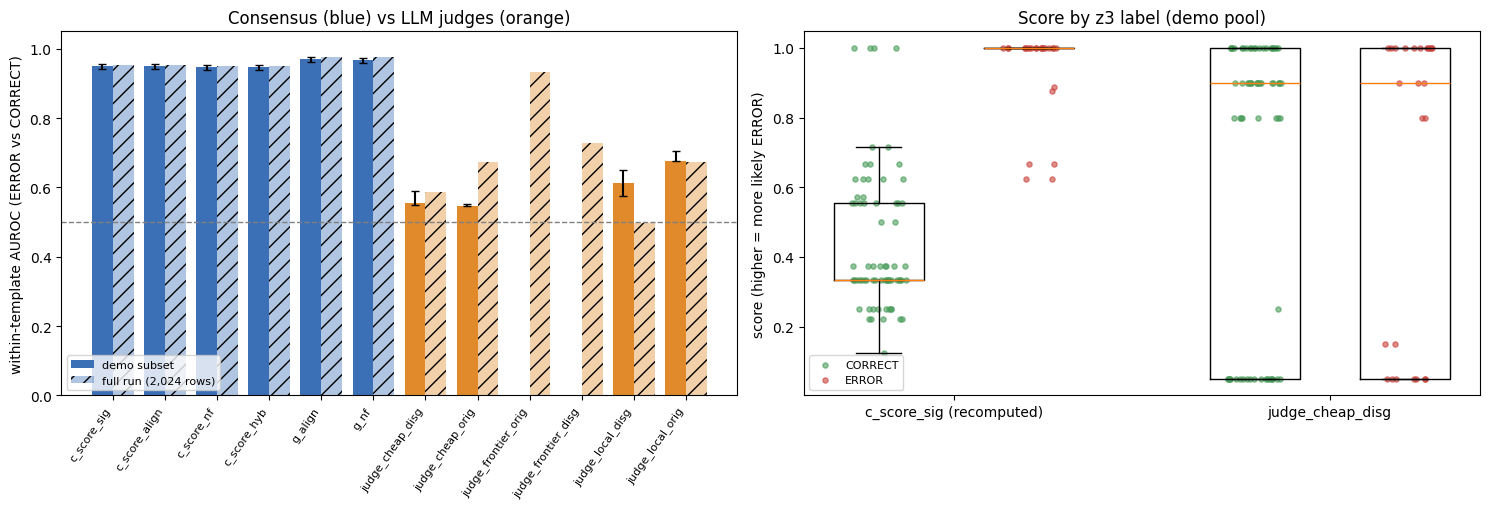

{
 "n_rows_demo": 100,
 "n_pool_primary": 94,
 "auroc_c_sig_demo": 0.9505208333333334,
 "auroc_judge_demo": 0.5546875,
 "delta_demo": 0.39583333333333337,
 "delta_ci_demo": [
  0.36363636363636365,
  0.39583333333333337
 ],
 "full_run_delta": 0.3671221036030572,
 "full_run_ci": [
  0.32842452732411576,
  0.40401256613475645
 ],
 "full_run_PASS": true,
 "consensus_recompute_match": "98/98",
 "consensus_secs": 2.1
}


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
ax = axes[0]
ms = [m for m in PRED]
x = np.arange(len(ms))
MIN_N_PLOT = 10   # hide demo bars resting on fewer rows (the frontier judge covers only 4 demo rows)
ok = [auc[m].get("auroc") is not None and auc[m]["n"] >= MIN_N_PLOT for m in ms]
demo_v = [auc[m]["auroc"] if ok[i] else np.nan for i, m in enumerate(ms)]
lo = [demo_v[i] - auc[m]["ci"][0] if ok[i] else 0 for i, m in enumerate(ms)]
hi = [auc[m]["ci"][1] - demo_v[i] if ok[i] else 0 for i, m in enumerate(ms)]
cols = ["#3b6fb6" if m.startswith(("c_", "g_")) else "#e08a2c" for m in ms]
ax.bar(x - 0.2, demo_v, 0.4, yerr=[lo, hi], color=cols, capsize=3, label="demo subset")
ax.bar(x + 0.2, [full_auc.get(m, np.nan) for m in ms], 0.4, color=cols, alpha=0.4, hatch="//", label="full run (2,024 rows)")
ax.axhline(0.5, ls="--", c="grey", lw=1)
ax.set_xticks(x); ax.set_xticklabels(ms, rotation=55, ha="right", fontsize=8)
ax.set_ylim(0, 1.05); ax.set_ylabel("within-template AUROC (ERROR vs CORRECT)")
ax.set_title("Consensus (blue) vs LLM judges (orange)"); ax.legend(loc="lower left", fontsize=8)

ax = axes[1]
lab = np.array([r["label"] for r in pool])
cs = np.array([recomputed[r["row_key"]]["score"] for r in pool], dtype=float)
jd = np.array([r[PRIMARY_BAR] for r in pool], dtype=float)
rng = np.random.default_rng(0)
for j, (name, v) in enumerate([("c_score_sig (recomputed)", cs), ("judge_cheap_disg", jd)]):
    for k, (L, c) in enumerate([("CORRECT", "#4a9d5b"), ("ERROR", "#c8423b")]):
        vv = v[lab == L]
        pos = j * 2.5 + k
        ax.boxplot(vv, positions=[pos], widths=0.6, showfliers=False)
        ax.scatter(pos + rng.uniform(-0.18, 0.18, len(vv)), vv, s=14, alpha=0.6, color=c, label=L if j == 0 else None)
ax.set_xticks([0.5, 3.0]); ax.set_xticklabels(["c_score_sig (recomputed)", "judge_cheap_disg"])
ax.set_ylabel("score (higher = more likely ERROR)"); ax.set_title("Score by z3 label (demo pool)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

summary = {"n_rows_demo": len(demo_rows), "n_pool_primary": prim["n"], "auroc_c_sig_demo": prim["auroc_metric"],
           "auroc_judge_demo": prim["auroc_comparator"], "delta_demo": prim["delta"], "delta_ci_demo": prim["ci"],
           "full_run_delta": fp["delta"], "full_run_ci": fp["ci"], "full_run_PASS": fp["PASS"],
           "consensus_recompute_match": f"{sum(agree)}/{len(agree)}", "consensus_secs": round(secs_consensus, 1)}
print(json.dumps(summary, indent=1))